In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob as glob
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from scipy.signal import detrend
from scipy.stats import linregress

# Read in data and calculate absolute error (2016-2024)

In [2]:
# Climatology
clim_file = '/glade/derecho/scratch/dcalhoun/ecmwf/era5/era5_2t_climatology_1991_2020_sorted.nc'
ds_clim = xr.open_dataset(clim_file)

In [ ]:
# Forecast (00z initialization time, 24 hour lead time)
fc_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/0000/24/*/*/*.nc'))
ds_fc = xr.open_mfdataset(fc_files)

In [ ]:
# Analysis
an_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/an/0.125/2t/*/*/*.nc'))
ds_an = xr.open_mfdataset(an_files)

In [6]:
# Ensure all times present in both fc and an
common_times = np.intersect1d(ds_fc['t2m'].time.values, ds_an['t2m'].time.values)
ds_fc = ds_fc.sel(time=common_times)
ds_an = ds_an.sel(time=common_times)

# Remove leap day
ds_fc = ds_fc.sel(time=~((ds_fc.time.dt.month == 2) & (ds_fc.time.dt.day == 29)))
ds_an = ds_an.sel(time=~((ds_an.time.dt.month == 2) & (ds_an.time.dt.day == 29)))

In [7]:
# Interpolate the climatology to the same grid as the forecast and analysis
ds_clim = ds_clim.sel(latitude=slice(ds_fc.latitude.min(), ds_fc.latitude.max()), longitude=slice(ds_fc.longitude.min(), ds_fc.longitude.max()))
ds_clim = ds_clim.interp(latitude = ds_fc.latitude.values, longitude = ds_fc.longitude.values, method='nearest')

# Calculate anomalies
ds_clim = ds_clim.sel(time=pd.to_datetime(ds_fc.time.dt.strftime('2017-%m-%d')).dayofyear) # align climatology to forecast data
ds_fc['t2m'] = (['time', 'latitude', 'longitude'], ds_fc['t2m'].values - ds_clim['2t'].values)
ds_an['t2m'] = (['time', 'latitude', 'longitude'], ds_an['t2m'].values - ds_clim['2t'].values)

In [8]:
ds_fc

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 3285, latitude: 201, longitude: 469)
Coordinates:
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * time       (time) datetime64[ns] 26kB 2016-01-02 2016-01-03 ... 2025-01-01
Data variables:
    t2m        (time, latitude, longitude) float64 2GB -2.186 -1.842 ... 0.5372
Attributes:
    Conventions:  CF-1.6
    history:      2025-04-09 19:14:33 GMT by grib_to_netcdf-2.34.0: grib_to_n...

In [9]:
ds_an

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 3285, latitude: 201, longitude: 469)
Coordinates:
  * longitude  (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
  * latitude   (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * time       (time) datetime64[ns] 26kB 2016-01-02 2016-01-03 ... 2025-01-01
Data variables:
    t2m        (time, latitude, longitude) float64 2GB -2.247 -1.7 ... 0.2689
Attributes:
    Conventions:  CF-1.6
    history:      2025-04-10 02:17:08 GMT by grib_to_netcdf-2.34.0: grib_to_n...

In [10]:
ds_abs_error = xr.Dataset({
                't2m_abs_error': (['time', 'latitude','longitude'], abs(ds_fc.t2m - ds_an.t2m).values)
                },
                coords = {
                    'time':(['time'], ds_fc.time.values),
                    'latitude' : (['latitude'], ds_fc.latitude.values),
                    'longitude' : (['longitude'], ds_fc.longitude.values)
                })      

In [11]:
ds_abs_error

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 3285, latitude: 201, longitude: 469)
Coordinates:
  * time           (time) datetime64[ns] 26kB 2016-01-02 ... 2025-01-01
  * latitude       (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude      (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
Data variables:
    t2m_abs_error  (time, latitude, longitude) float64 2GB 0.06156 ... 0.2683

In [24]:
ds_abs_error.to_netcdf('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/error/0.125/2t/0000/24/ifs_2t_abs_error_0000_24_2016_2024.nc')

# Absolute Error Analysis

In [2]:
ds_abs_error = xr.open_dataset('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/error/0.125/2t/0000/24/ifs_2t_abs_error_0000_24_2016_2024.nc')

In [3]:
ds_abs_error

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 3285, latitude: 201, longitude: 469)
Coordinates:
  * time           (time) datetime64[ns] 26kB 2016-01-02 ... 2025-01-01
  * latitude       (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude      (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
Data variables:
    t2m_abs_error  (time, latitude, longitude) float64 2GB ...

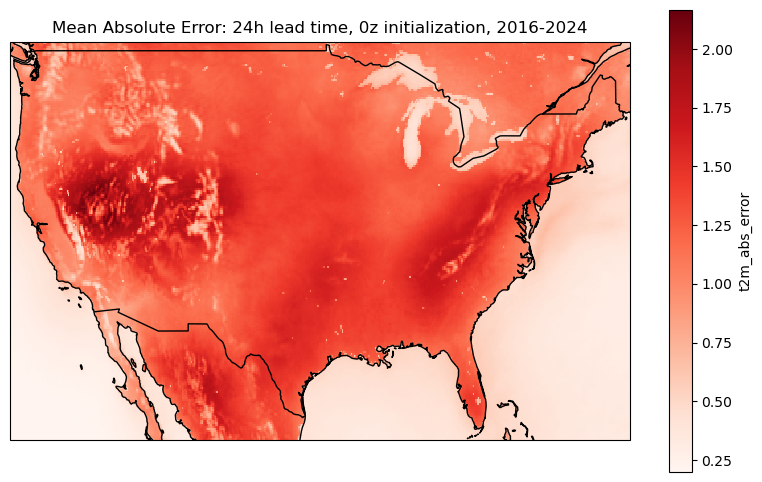

In [4]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ds_abs_error.t2m_abs_error.mean(axis=0).plot(cmap='Reds')
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)
ax.set_aspect(1.5)
plt.title('Mean Absolute Error: 24h lead time, 0z initialization, 2016-2024')
plt.show()

DJF 2.6905135845917325
MAM 2.528391255824178
JJA 2.02788135471821
SON 2.153322019586387


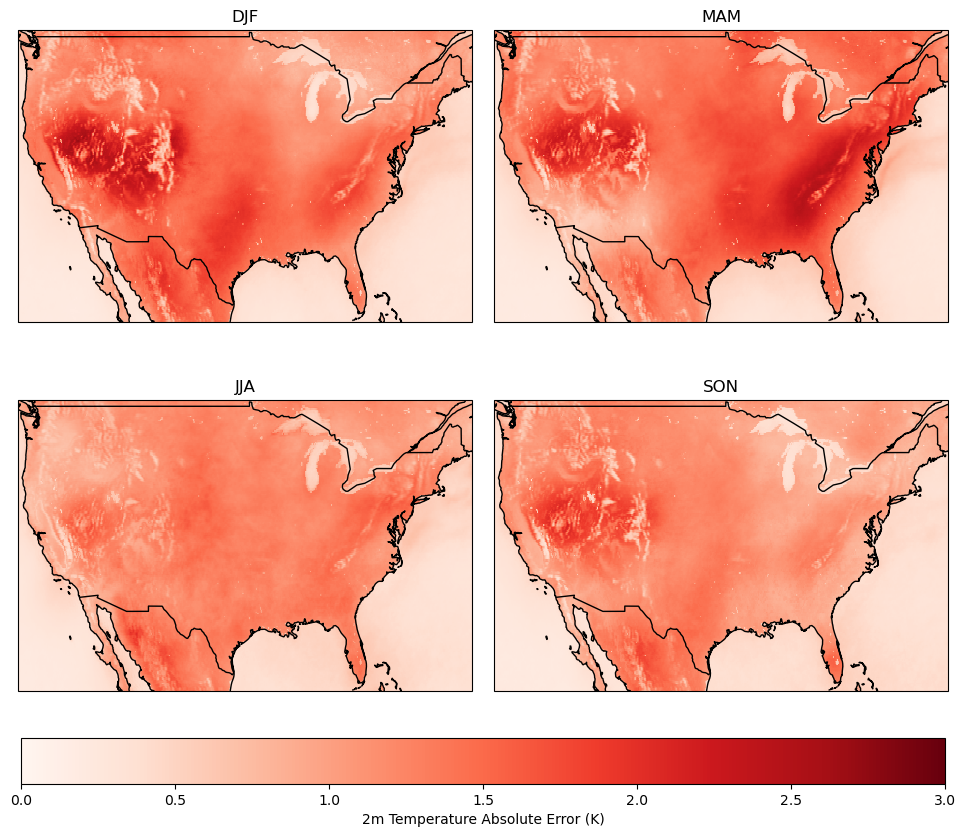

In [5]:
seasons = {'DJF': [12,1,2], 'MAM': [3,4,5], 'JJA': [6,7,8], 'SON': [9, 10, 11]}

fig, ax = plt.subplots(2,2, figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

for i, season in enumerate(seasons.keys()):
    ds_season = ds_abs_error.sel(time=ds_abs_error.time.dt.month.isin(seasons[season])).t2m_abs_error.mean(axis=0)
    print(season, ds_season.max().values)
    im = ds_season.plot(cmap='Reds', ax=ax[i//2, i%2], vmin=0, vmax=3, add_colorbar=False)
    ax[i//2, i%2].add_feature(cfeature.BORDERS)
    ax[i//2, i%2].add_feature(cfeature.COASTLINE)
    ax[i//2, i%2].set_aspect(1.5)
    ax[i//2, i%2].set_title(season)
plt.subplots_adjust(wspace=0.05, hspace=-0.2)


cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.05, label='2m Temperature Absolute Error (K)')
plt.show()

In [6]:
ds_abs_error_detrend = xr.Dataset({
                't2m_abs_error': (['time', 'latitude','longitude'], detrend(ds_abs_error.t2m_abs_error.values, axis=0))
                },
                coords = {
                    'time':(['time'], ds_abs_error.time.values),
                    'latitude' : (['latitude'], ds_abs_error.latitude.values),
                    'longitude' : (['longitude'], ds_abs_error.longitude.values)
                })      

In [7]:
ds_abs_error_detrend

<xarray.Dataset> Size: 2GB
Dimensions:        (time: 3285, latitude: 201, longitude: 469)
Coordinates:
  * time           (time) datetime64[ns] 26kB 2016-01-02 ... 2025-01-01
  * latitude       (latitude) float32 804B 49.5 49.38 49.25 ... 24.75 24.62 24.5
  * longitude      (longitude) float32 2kB -125.0 -124.9 -124.8 ... -66.62 -66.5
Data variables:
    t2m_abs_error  (time, latitude, longitude) float64 2GB -1.046 ... -0.1238

In [8]:
weights = np.cos(np.deg2rad(ds_abs_error_detrend.latitude))
weights.name = "weights"
ds_abs_error_weighted = ds_abs_error_detrend.weighted(weights)

In [9]:
MAE = xr.Dataset({
                'MAE': (['time'], ds_abs_error_weighted.mean(dim=['latitude', 'longitude']).t2m_abs_error.values)
                },
                coords = {
                    'time':(['time'], ds_abs_error.time.values),
                    'dayofyear':(['time'], pd.to_datetime(ds_abs_error.time.dt.strftime('2017-%m-%d')).dayofyear)
                })  

In [10]:
MAE

<xarray.Dataset> Size: 66kB
Dimensions:    (time: 3285)
Coordinates:
  * time       (time) datetime64[ns] 26kB 2016-01-02 2016-01-03 ... 2025-01-01
    dayofyear  (time) int32 13kB 2 3 4 5 6 7 8 9 ... 360 361 362 363 364 365 1
Data variables:
    MAE        (time) float64 26kB -0.2671 -0.09736 -0.09217 ... 0.01466 -0.2129

In [11]:
MAE_clim = MAE.groupby('dayofyear').mean()

In [12]:
MAE_clim

<xarray.Dataset> Size: 4kB
Dimensions:    (dayofyear: 365)
Coordinates:
  * dayofyear  (dayofyear) int32 1kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    MAE        (dayofyear) float64 3kB -0.04238 -0.05009 ... -0.03944 0.008083

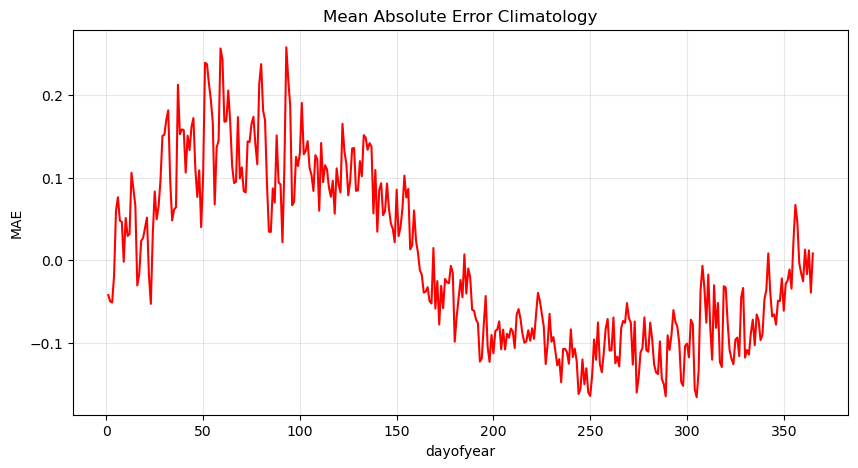

In [13]:
fig, ax = plt.subplots(1, figsize=(10,5))
MAE_clim.MAE.plot(c='r', ax=ax)
plt.title('Mean Absolute Error Climatology')
plt.grid(alpha=0.3)
plt.show()

In [14]:
abs_error_anom = ds_abs_error_detrend.t2m_abs_error.values - MAE_clim.MAE.sel(dayofyear = pd.to_datetime(MAE.time.dt.strftime('2017-%m-%d')).dayofyear).values[:,np.newaxis,np.newaxis]

ds_abs_error_anom = xr.Dataset({
                't2m_abs_error_anom': (['time', 'latitude', 'longitude'], abs_error_anom)
                },
                coords = {
                    'time':(['time'], ds_abs_error.time.values),
                    'latitude' : (['latitude'], ds_abs_error.latitude.values),
                    'longitude' : (['longitude'], ds_abs_error.longitude.values)
                })  

In [15]:
ds_abs_error_anom

<xarray.Dataset> Size: 2GB
Dimensions:             (time: 3285, latitude: 201, longitude: 469)
Coordinates:
  * time                (time) datetime64[ns] 26kB 2016-01-02 ... 2025-01-01
  * latitude            (latitude) float32 804B 49.5 49.38 49.25 ... 24.62 24.5
  * longitude           (longitude) float32 2kB -125.0 -124.9 ... -66.62 -66.5
Data variables:
    t2m_abs_error_anom  (time, latitude, longitude) float64 2GB -0.9963 ... -...

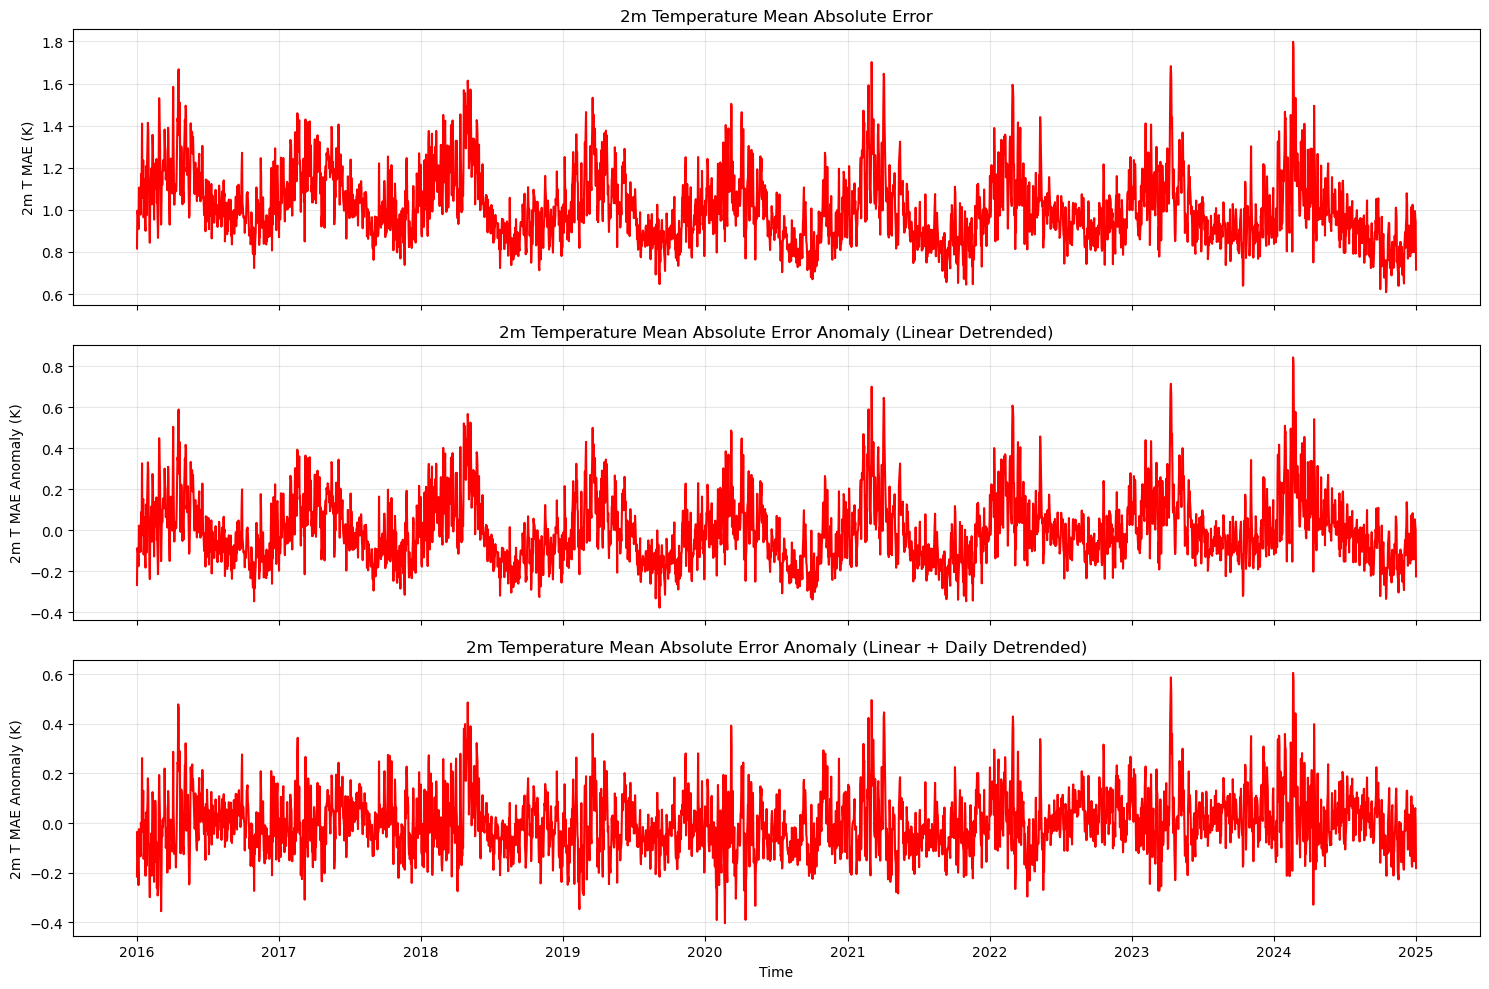

In [16]:
fig, ax = plt.subplots(3, 1, figsize=(15,10), sharex=True)
ds_abs_error.t2m_abs_error.mean(axis=1).mean(axis=1).plot(c='r', ax=ax[0])
ax[0].set_title('2m Temperature Mean Absolute Error')
ax[0].set_xlabel('')
ax[0].set_ylabel('2m T MAE (K)')
ax[0].grid(alpha=0.3)

ds_abs_error_detrend.t2m_abs_error.mean(axis=1).mean(axis=1).plot(c='r', ax=ax[1])
ax[1].set_title('2m Temperature Mean Absolute Error Anomaly (Linear Detrended)')
ax[1].set_xlabel('')
ax[1].set_ylabel('2m T MAE Anomaly (K)')
ax[1].grid(alpha=0.3)

ds_abs_error_anom.t2m_abs_error_anom.mean(axis=1).mean(axis=1).plot(c='r', ax=ax[2])
ax[2].set_title('2m Temperature Mean Absolute Error Anomaly (Linear + Daily Detrended)')
ax[2].set_ylabel('2m T MAE Anomaly (K)')
ax[2].grid(alpha=0.3)

plt.xlabel('Time')
plt.tight_layout()
plt.show()

In [17]:
idxs = [np.random.randint(3285) for i in range(9)]

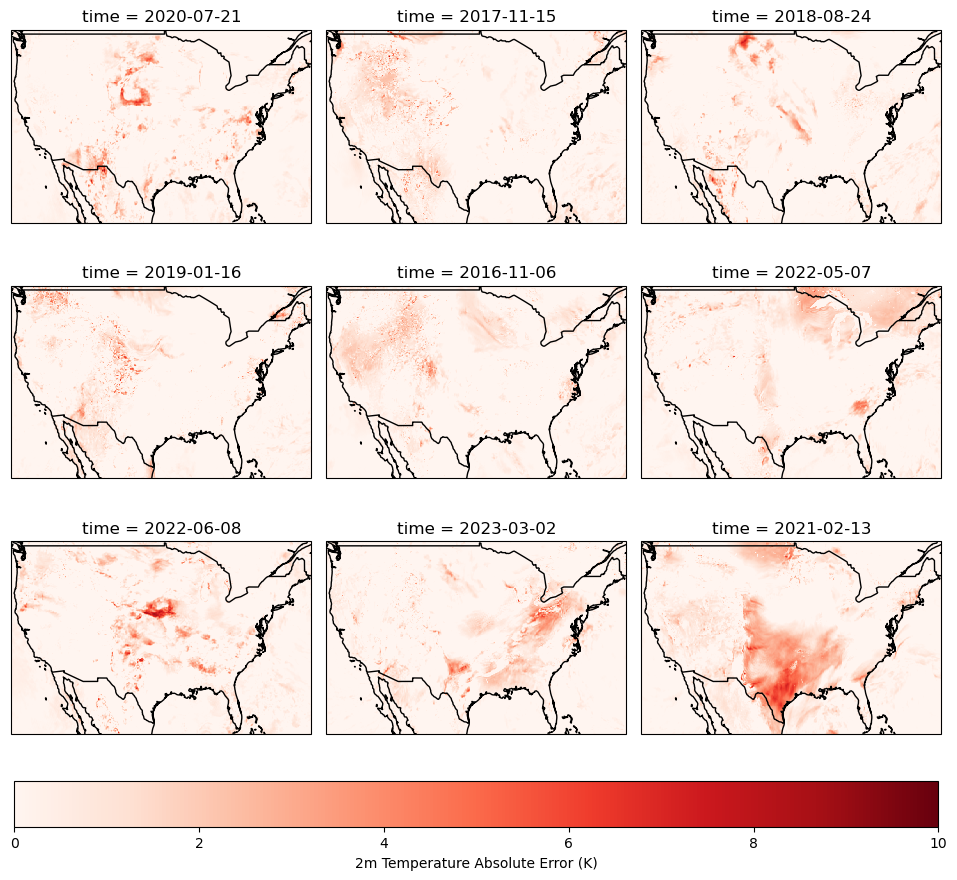

In [18]:
fig, ax = plt.subplots(3,3, figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})
for i in range(9):
    ds = ds_abs_error_detrend.t2m_abs_error.isel(time=idxs[i])
    im = ds.plot(cmap='Reds', ax=ax[i//3, i%3], vmin=0, vmax=10, add_colorbar=False)
    ax[i//3, i%3].add_feature(cfeature.BORDERS)
    ax[i//3, i%3].add_feature(cfeature.COASTLINE)
    ax[i//3, i%3].set_aspect(1.5)
plt.subplots_adjust(wspace=0.05, hspace=-0.2)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.05, label='2m Temperature Absolute Error (K)')
plt.show()

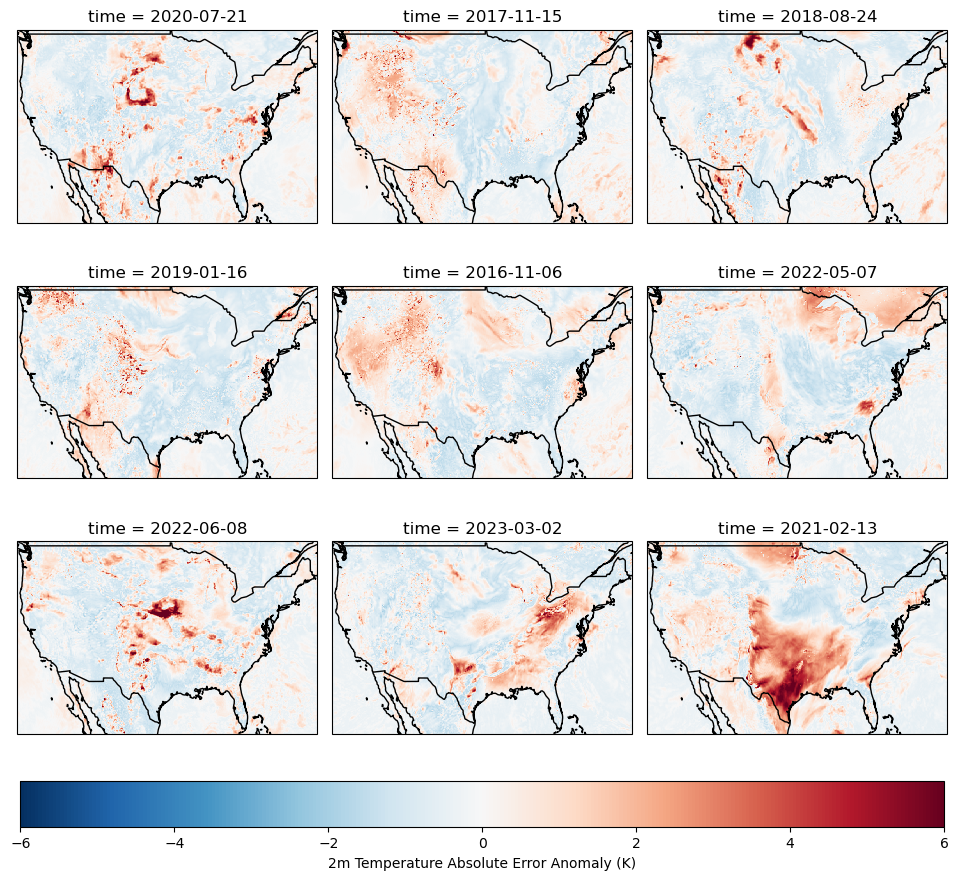

In [19]:
fig, ax = plt.subplots(3,3, figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})
for i in range(9):
    ds = ds_abs_error_anom.t2m_abs_error_anom.isel(time=idxs[i])
    im = ds.plot(cmap='RdBu_r', ax=ax[i//3, i%3], vmin=-6, vmax=6, add_colorbar=False)
    ax[i//3, i%3].add_feature(cfeature.BORDERS)
    ax[i//3, i%3].add_feature(cfeature.COASTLINE)
    ax[i//3, i%3].set_aspect(1.5)
plt.subplots_adjust(wspace=0.05, hspace=-0.2)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.05, label='2m Temperature Absolute Error Anomaly (K)')
plt.show()

In [20]:
ds_abs_error_anom.to_netcdf('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/error/0.125/2t/0000/24/ifs_2t_abs_error_anom_0000_24_2016_2024.nc')

# Extra

In [91]:
original = ds_abs_error.mean(('latitude','longitude')).t2m_abs_error.values
linear = detrend(ds_abs_error.t2m_abs_error, type='linear', axis=0).mean(axis=1).mean(axis=1) + original.mean()
regression = linregress(np.arange(len(original)), original)

In [92]:
x = np.arange(len(original))
y = regression[0] * x + regression[1]

In [124]:
original.mean()

np.float64(1.0114458403003581)

In [125]:
linear.mean()

np.float64(1.0114458403003583)

In [143]:
y.mean()

np.float64(1.0114458403003581)

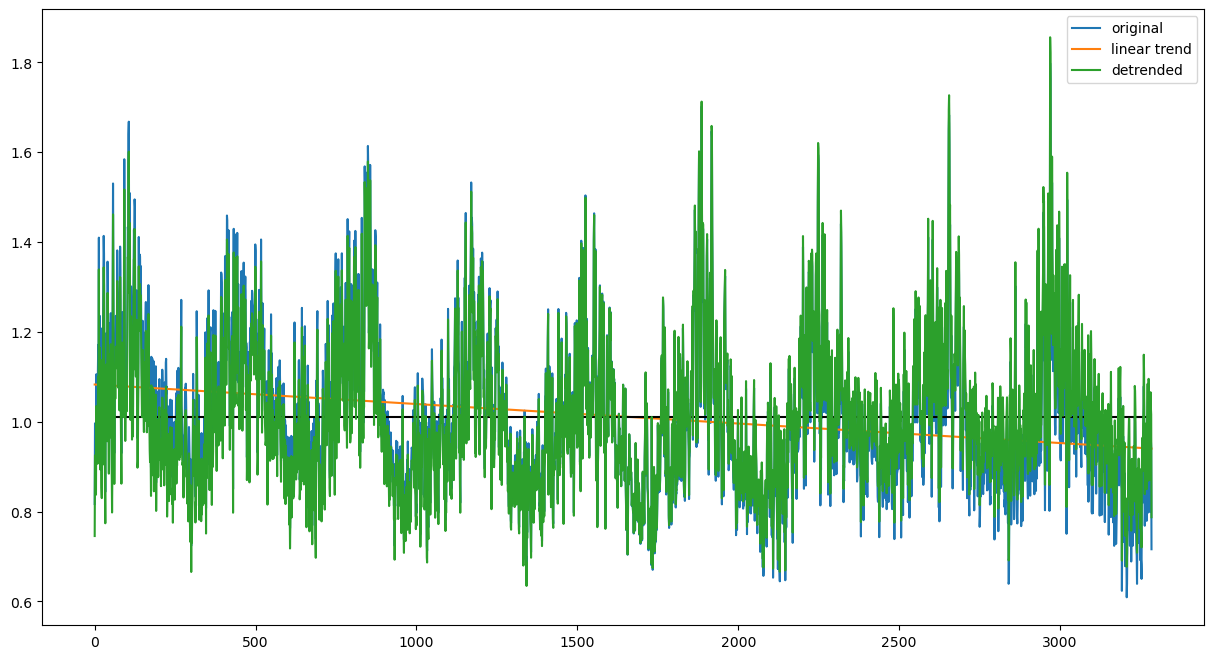

In [142]:
plt.subplots(figsize=(15,8))
plt.plot(original, label='original')
plt.plot(y, label='linear trend')
plt.hlines(y.mean(), x.min(), x.max(), color='k')

plt.plot(linear, label='detrended')
plt.legend()
plt.show()

# Köppen Climate Regions

In [2]:
ds_kop = xr.open_dataset('/glade/derecho/scratch/dcalhoun/koppen_geiger_nc/1991_2020/koppen_geiger_0p00833333.nc')

In [3]:
ds_kop

<xarray.Dataset> Size: 7GB
Dimensions:        (lon: 43200, lat: 21600)
Coordinates:
  * lon            (lon) float64 346kB -180.0 -180.0 -180.0 ... 180.0 180.0
  * lat            (lat) float64 173kB 90.0 89.99 89.98 ... -89.98 -89.99 -90.0
Data variables:
    kg_class       (lat, lon) float32 4GB ...
    kg_confidence  (lat, lon) float32 4GB ...
Attributes:
    history:  Created on 2024-01-21 12:25

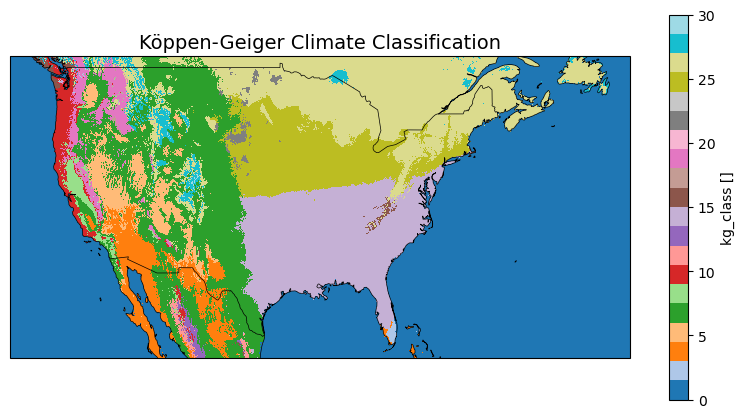

In [4]:
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the kg_class variable
im = ds_kop['kg_class'].sel(lat=slice(50,24), lon=slice(-130, -50)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='tab20',  # Categorical colormap
    add_colorbar=True
)

# Add map features
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.set_title('Köppen-Geiger Climate Classification', fontsize=14)
ax.set_aspect(1.5)

plt.show()